In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader,random_split,Subset,WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
from PIL import Image,ImageFile
import timm

In [18]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [19]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
import kagglehub
path = kagglehub.dataset_download("andrewmvd/isic-2019")
print(path)

/kaggle/input/isic-2019


In [21]:
training_csv=pd.read_csv(f"/kaggle/input/isic-2019/ISIC_2019_Training_GroundTruth.csv")

In [22]:
training_csv.head(10)

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,ISIC_0000006,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,ISIC_0000007,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,ISIC_0000008,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,ISIC_0000009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,ISIC_0000010,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
training_csv.tail(10)

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
25321,ISIC_0073240,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25322,ISIC_0073241,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25323,ISIC_0073244,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25324,ISIC_0073245,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25325,ISIC_0073246,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25326,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25327,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25328,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25329,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25330,ISIC_0073254,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [24]:
training_csv.shape

(25331, 10)

In [25]:
training_csv["UNK"].sum() #All the labels are known

np.float64(0.0)

In [26]:
images_dirpath="/kaggle/input/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

In [27]:
!ls /kaggle/input/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input | head

ATTRIBUTION.txt
ISIC_0000000.jpg
ISIC_0000001.jpg
ISIC_0000002.jpg
ISIC_0000003.jpg
ISIC_0000004.jpg
ISIC_0000006.jpg
ISIC_0000007.jpg
ISIC_0000008.jpg
ISIC_0000009.jpg
ls: write error: Broken pipe


In [28]:
# plt.imshow(plt.imread(f'{images_dirpath}/ISIC_0000009.jpg'))
# plt.show()

In [29]:
sample_image=plt.imread(f'{images_dirpath}/ISIC_0000006.jpg')
print(sample_image.shape)

(767, 1022, 3)


In [30]:
# Organizing the Data
!path="/kaggle/input/isic-2019"
!ls $path

ISIC_2019_Training_GroundTruth.csv  ISIC_2019_Training_Metadata.csv
ISIC_2019_Training_Input


In [31]:
if not os.path.isdir("Image_Classifiers"):
  os.mkdir("Image_Classifiers")

In [32]:
idx=0
for image_name in training_csv["image"]:
  class_dir_path="Image_Classifiers"
  for cancer_type in range(1,9):
    if training_csv.iloc[idx,cancer_type].astype('int') == 1:
      class_dir_path=os.path.join(class_dir_path,f"class_label_{cancer_type}")
  if not os.path.isdir(class_dir_path):
    os.mkdir(class_dir_path)
  image_path=os.path.join(class_dir_path,f"{image_name}.jpg")
  orig_image_path=f"{images_dirpath}/{image_name}.jpg"
  if not os.path.isfile(image_path):
    shutil.copy(orig_image_path,image_path)
  idx+=1

In [33]:
corrupted_files=[]
fraction_classes=np.zeros(8)
i=0
for sub_folder in os.listdir("Image_Classifiers"):
  for img in os.listdir(os.path.join("Image_Classifiers",sub_folder)):
    i+=1
    img_path=os.path.join("Image_Classifiers",sub_folder,img)
    try:
      with Image.open(img_path) as checking_img:
        checking_img.verify()
    except:
      corrupted_files.append(img_path)
  print(os.path.join("Image_Classifiers",sub_folder),i)
  # print(sub_folder.split('_')[2])
  fraction_classes[int(sub_folder.split('_')[2])-1]=i
  i=0
fraction_classes

Image_Classifiers/class_label_2 12875
Image_Classifiers/class_label_6 239
Image_Classifiers/class_label_5 2624
Image_Classifiers/class_label_8 628
Image_Classifiers/class_label_7 253
Image_Classifiers/class_label_4 867
Image_Classifiers/class_label_1 4522
Image_Classifiers/class_label_3 3323


array([ 4522., 12875.,  3323.,   867.,  2624.,   239.,   253.,   628.])

In [34]:
fraction_classes/=np.sum(fraction_classes)

In [35]:
print(corrupted_files)
for file in corrupted_files:
  os.remove(file)

[]


In [98]:
dataset = datasets.ImageFolder("Image_Classifiers")
total_size=len(dataset)
train_batch_size=int(0.8*total_size)
test_batch_size=int(0.05*total_size)

train_idx, test_idx,_ = random_split(
    range(total_size),
    [train_batch_size, test_batch_size, total_size-train_batch_size-test_batch_size]
    )

input_img_size=384

train_transform = transforms.Compose([
    transforms.Resize((input_img_size,input_img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((input_img_size,input_img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

visual_transform = transforms.Compose([
    transforms.Resize((input_img_size,input_img_size)),
    transforms.ToTensor()
])

train_dataset = Subset(
    datasets.ImageFolder("Image_Classifiers", transform=train_transform),
    train_idx
)

test_dataset = Subset(
    datasets.ImageFolder("Image_Classifiers", transform=test_transform),
    test_idx
)

visual_test_dataset = Subset(
    datasets.ImageFolder("Image_Classifiers", transform=visual_transform),
    test_idx
)

targets = np.array(train_dataset.dataset.targets)[train_dataset.indices]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts

sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
# sampler=WeightesRandomSampler(weights=)
train_loader=DataLoader(train_dataset,batch_size=64,sampler=sampler)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=True)
visual_test_loader=DataLoader(visual_test_dataset,batch_size=24,shuffle=True)


In [99]:
total_size

25331

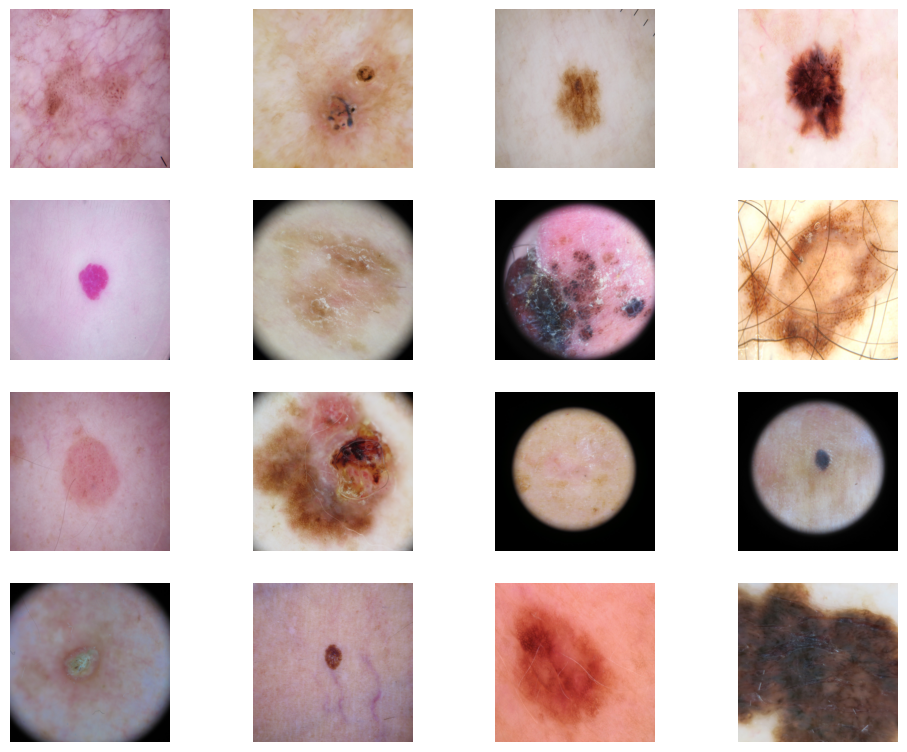

In [100]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
def visualize(visualizer_loader,n=5):
    x, y = next(iter(visualizer_loader))
    x, y = x.to(device), y.to(device)
    plt.figure(figsize=(12,12))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(x[i].cpu().squeeze().permute(1,2,0))
        plt.axis('off')
    plt.show()
visualize(visual_test_loader,16)

In [41]:
def train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,epochs=5):
  for epoch in range(epochs):
    model.train()
    total_loss=0
    total=0
    correct=0
    step=0
    for x,y in train_loader:
      step+=1
      x,y=x.to(device),y.to(device)
      optimizer.zero_grad()
      logits=model(x)
      loss=loss_fn(logits,y)
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()
      pred=logits.argmax(dim=1)
      correct+=(pred==y).sum().item()
      total+=y.size(0)
      if step%20==0:
          print(f"Step {step} : Intermediate Accuracy = {100*correct/total :.2f}")
    print(f"Epoch {epoch+1}")
    print(f"Loss : {total_loss:.4f}")
    print("Training Accuracy")
    train_accuracy.append(100*correct/total)
    print(f"Accuracy: {100*correct/total :.2f}")
    print("Testing Accuracy")
    test_accuracy.append(test_model(model,test_loader))
    # train_accuracy.append(test_model(model,train_loader))

def test_model(model,test_loader):
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for x,y in test_loader:
      x,y=x.to(device),y.to(device)
      logits=model(x)
      pred=logits.argmax(dim=1)
      correct+=(pred==y).sum().item()
      total+=y.size(0)
  print(f"Accuracy: {100*correct/total :.2f}")
  return 100*correct/total

In [42]:
#Vision Transformer

In [48]:
model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=True,
    num_classes=8
)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [52]:
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)

Step 20 : Intermediate Accuracy = 27.97
Step 40 : Intermediate Accuracy = 30.12
Step 60 : Intermediate Accuracy = 32.92
Step 80 : Intermediate Accuracy = 35.08
Step 100 : Intermediate Accuracy = 36.09
Step 120 : Intermediate Accuracy = 37.33
Step 140 : Intermediate Accuracy = 38.86
Step 160 : Intermediate Accuracy = 40.72
Step 180 : Intermediate Accuracy = 42.08
Step 200 : Intermediate Accuracy = 43.05
Step 220 : Intermediate Accuracy = 44.40
Step 240 : Intermediate Accuracy = 45.30
Step 260 : Intermediate Accuracy = 46.45
Step 280 : Intermediate Accuracy = 47.25
Step 300 : Intermediate Accuracy = 48.36
Epoch 1
Loss : 421.7073
Training Accuracy
Accuracy: 49.11
Testing Accuracy
Accuracy: 58.29
Step 20 : Intermediate Accuracy = 64.69
Step 40 : Intermediate Accuracy = 64.14
Step 60 : Intermediate Accuracy = 64.74
Step 80 : Intermediate Accuracy = 65.45
Step 100 : Intermediate Accuracy = 66.27
Step 120 : Intermediate Accuracy = 67.54
Step 140 : Intermediate Accuracy = 67.97
Step 160 : Inte

68.48341232227489

In [53]:
model9=model
train_accuracy_9=train_accuracy
test_accuracy_9=test_accuracy
test_model(model9,test_loader)

Accuracy: 68.48


68.48341232227489

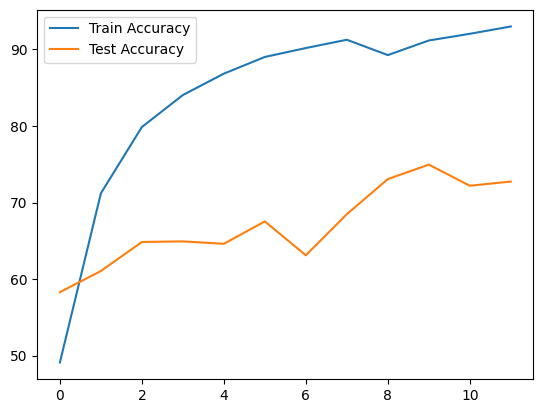

In [96]:
plt.plot(train_accuracy_9,label="Train Accuracy")
plt.plot(test_accuracy_9,label="Test Accuracy")
plt.legend()
plt.show()

In [61]:
model

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [65]:
model = timm.create_model('vit_base_patch32_384.augreg_in1k', pretrained=True)
model=nn.Sequential(model,
                   nn.Linear(1000,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Linear(128,8),
                   )
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)

Step 20 : Intermediate Accuracy = 37.66
Step 40 : Intermediate Accuracy = 44.18
Step 60 : Intermediate Accuracy = 47.94
Step 80 : Intermediate Accuracy = 50.47
Step 100 : Intermediate Accuracy = 53.03
Step 120 : Intermediate Accuracy = 54.91
Step 140 : Intermediate Accuracy = 56.92
Step 160 : Intermediate Accuracy = 58.14
Step 180 : Intermediate Accuracy = 59.42
Step 200 : Intermediate Accuracy = 60.03
Step 220 : Intermediate Accuracy = 61.09
Step 240 : Intermediate Accuracy = 61.95
Step 260 : Intermediate Accuracy = 62.72
Step 280 : Intermediate Accuracy = 63.49
Step 300 : Intermediate Accuracy = 64.15
Epoch 1
Loss : 310.9480
Training Accuracy
Accuracy: 64.75
Testing Accuracy
Accuracy: 55.53
Step 20 : Intermediate Accuracy = 76.64
Step 40 : Intermediate Accuracy = 75.66
Step 60 : Intermediate Accuracy = 74.06
Step 80 : Intermediate Accuracy = 74.63
Step 100 : Intermediate Accuracy = 74.59
Step 120 : Intermediate Accuracy = 74.86
Step 140 : Intermediate Accuracy = 75.67
Step 160 : Inte

63.665086887835706

In [ ]:
model10=model
train_accuracy_10=train_accuracy
test_accuracy_10=test_accuracy
test_model(model10,test_loader)

Accuracy: 63.67


63.665086887835706

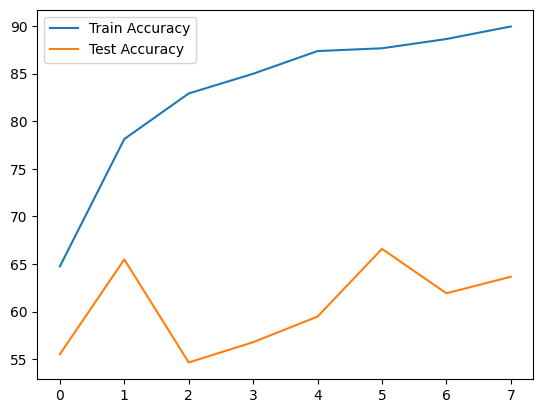

In [ ]:
plt.plot(train_accuracy_10,label="Train Accuracy")
plt.plot(test_accuracy_10,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
model = timm.create_model(
    'vit_base_patch32_384.augreg_in1k',
    pretrained=True,
    num_classes=0   # replaces head automatically
)
for name, param in model.named_parameters():
    if "head" not in name:
        param.requires_grad = False
model=nn.Sequential(model,
                   nn.Linear(768,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Linear(128,8),
                   )
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)

Step 20 : Intermediate Accuracy = 28.67
Step 40 : Intermediate Accuracy = 35.62
Step 60 : Intermediate Accuracy = 41.20
Step 80 : Intermediate Accuracy = 44.20
Step 100 : Intermediate Accuracy = 47.39
Step 120 : Intermediate Accuracy = 49.61
Step 140 : Intermediate Accuracy = 51.64
Step 160 : Intermediate Accuracy = 53.35
Step 180 : Intermediate Accuracy = 54.83
Step 200 : Intermediate Accuracy = 56.15
Step 220 : Intermediate Accuracy = 56.93
Step 240 : Intermediate Accuracy = 57.92
Step 260 : Intermediate Accuracy = 58.73
Step 280 : Intermediate Accuracy = 59.58
Step 300 : Intermediate Accuracy = 60.26
Epoch 1
Loss : 374.1960
Training Accuracy
Accuracy: 60.80
Testing Accuracy
Accuracy: 62.80
Step 20 : Intermediate Accuracy = 71.72
Step 40 : Intermediate Accuracy = 71.41
Step 60 : Intermediate Accuracy = 71.41
Step 80 : Intermediate Accuracy = 72.15
Step 100 : Intermediate Accuracy = 72.55
Step 120 : Intermediate Accuracy = 72.79
Step 140 : Intermediate Accuracy = 73.21
Step 160 : Inte

71.01105845181675

In [ ]:
model11=model
train_accuracy_11=train_accuracy
test_accuracy_11=test_accuracy
test_model(model11,test_loader)

Accuracy: 71.01


71.01105845181675

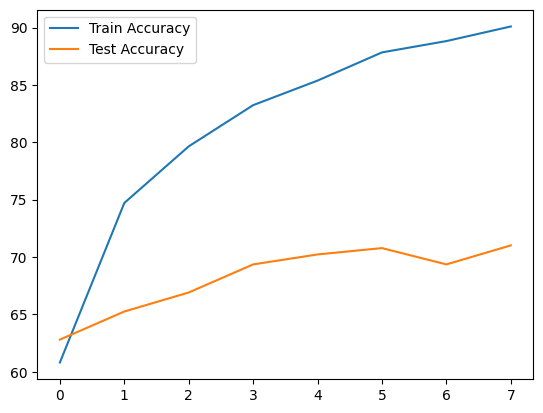

In [ ]:
plt.plot(train_accuracy_11,label="Train Accuracy")
plt.plot(test_accuracy_11,label="Test Accuracy")
plt.legend()
plt.show()

In [76]:
optimizer=optim.Adam(model9.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model9,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,4)
test_model(model9,test_loader)

Step 20 : Intermediate Accuracy = 85.94
Step 40 : Intermediate Accuracy = 85.35
Step 60 : Intermediate Accuracy = 85.70
Step 80 : Intermediate Accuracy = 86.82
Step 100 : Intermediate Accuracy = 87.31
Step 120 : Intermediate Accuracy = 87.72
Step 140 : Intermediate Accuracy = 87.89
Step 160 : Intermediate Accuracy = 88.31
Step 180 : Intermediate Accuracy = 88.42
Step 200 : Intermediate Accuracy = 88.52
Step 220 : Intermediate Accuracy = 88.66
Step 240 : Intermediate Accuracy = 88.88
Step 260 : Intermediate Accuracy = 89.10
Step 280 : Intermediate Accuracy = 89.17
Step 300 : Intermediate Accuracy = 89.19
Epoch 1
Loss : 98.3220
Training Accuracy
Accuracy: 89.27
Testing Accuracy
Accuracy: 73.06
Step 20 : Intermediate Accuracy = 88.91
Step 40 : Intermediate Accuracy = 89.84
Step 60 : Intermediate Accuracy = 90.23
Step 80 : Intermediate Accuracy = 90.43
Step 100 : Intermediate Accuracy = 90.34
Step 120 : Intermediate Accuracy = 90.73
Step 140 : Intermediate Accuracy = 90.60
Step 160 : Inter

72.74881516587678

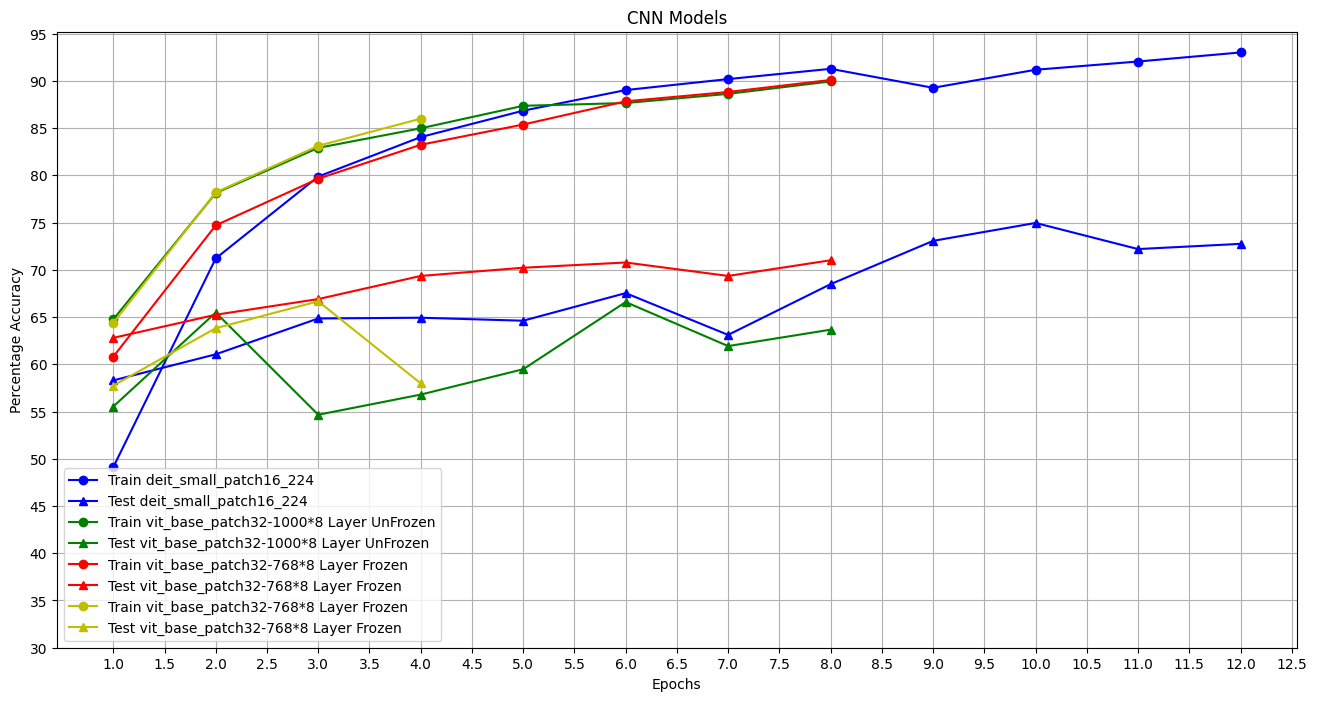

In [109]:
plt.figure(figsize=(16,8))
plt.plot(np.arange(1,13),train_accuracy_9,marker='o',c='b',label="Train deit_small_patch16_224")
plt.plot(np.arange(1,13),test_accuracy_9,marker='^',c='b',label="Test deit_small_patch16_224")
plt.plot(np.arange(1,9),train_accuracy_10,marker='o',c='g',label="Train vit_base_patch32-1000*8 Layer UnFrozen")
plt.plot(np.arange(1,9),test_accuracy_10,marker='^',c='g',label="Test vit_base_patch32-1000*8 Layer UnFrozen")
plt.plot(np.arange(1,9),train_accuracy_11,marker='o',c='r',label="Train vit_base_patch32-768*8 Layer Frozen")
plt.plot(np.arange(1,9),test_accuracy_11,marker='^',c='r',label="Test vit_base_patch32-768*8 Layer Frozen")
plt.plot(np.arange(1,5),train_accuracy_12,marker='o',c='y',label="Train vit_base_patch32-768*8 Layer Frozen")
plt.plot(np.arange(1,5),test_accuracy_12,marker='^',c='y',label="Test vit_base_patch32-768*8 Layer Frozen")
plt.legend()
plt.grid()
plt.title("CNN Models")
plt.xlabel("Epochs")
plt.ylabel("Percentage Accuracy")
plt.xticks(np.arange(1,13,0.5))
plt.yticks(np.arange(30,100,5))
plt.show()

In [46]:
class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x):
        return nn.functional.relu(self.fn(x) + x)
def conv_block(input_channel,output_channel):
    return nn.Sequential(
        nn.Conv2d(input_channel, output_channel, 3, padding=1),
        nn.BatchNorm2d(output_channel),
        nn.ReLU(),
        nn.Conv2d(output_channel, output_channel, 3, padding=1),
        nn.BatchNorm2d(output_channel)
    )

In [ ]:
# model=CNN_Model()
#Image Dimensions 64*64
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2,2),
    # nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2,2),
    # nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2,2),
    # nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(12*12*128,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    # nn.Dropout(0.3),
    nn.Linear(128,8)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)


In [ ]:
model1=model
train_accuracy_1=train_accuracy
test_accuracy_1=test_accuracy
test_model(model1,test_loader)

In [ ]:
plt.plot(train_accuracy_1,label="Train Accuracy")
plt.plot(test_accuracy_1,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
# model=CNN_Model()
#Image Dimensions 64*64
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Flatten(),
    nn.Linear(12*12*128,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.3),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.1),
    nn.Linear(128,8)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)


In [ ]:
model2=model
train_accuracy_2=train_accuracy
test_accuracy_2=test_accuracy
test_model(model2,test_loader)

In [ ]:
plt.plot(train_accuracy_2,label="Train Accuracy")
plt.plot(test_accuracy_2,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
# model=CNN_Model()
#Image Dimensions 64*64
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    Residual(conv_block(32,32)),
    nn.MaxPool2d(2,2),
    # nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    Residual(conv_block(64,64)),
    nn.MaxPool2d(2,2),
    # nn.Dropout(0.3),
    # Residual(conv_block(128,128)),
    nn.MaxPool2d(2,2),
    # nn.Dropout(0.3),
    nn.Flatten(),
    nn.Linear(12*12*64,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128,8)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)


In [ ]:
model3=model
train_accuracy_3=train_accuracy
test_accuracy_3=test_accuracy
test_model(model3,test_loader)

In [ ]:
plt.plot(train_accuracy_3,label="Train Accuracy")
plt.plot(test_accuracy_3,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
# model=CNN_Model()
#Image Dimensions 64*64
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    Residual(conv_block(32,32)),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    Residual(conv_block(64,64)),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    # Residual(conv_block(128,128)),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Flatten(),
    nn.Linear(12*12*64,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.3),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.1),
    nn.Linear(128,8)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,8)
test_model(model,test_loader)


In [ ]:
model4=model
train_accuracy_4=train_accuracy
test_accuracy_4=test_accuracy
test_model(model4,test_loader)

In [ ]:
plt.plot(train_accuracy_4,label="Train Accuracy")
plt.plot(test_accuracy_4,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(np.arange(1,9),train_accuracy_1,marker='o',c='b',label="Train Acc DeepCNN")
plt.plot(np.arange(1,9),test_accuracy_1,marker='^',c='b',label="Test Acc DeepCNN")
plt.plot(np.arange(1,9),train_accuracy_2,marker='o',c='g',label="Train Acc DeepCNN+Dropout")
plt.plot(np.arange(1,9),test_accuracy_2,marker='^',c='g',label="Test Acc DeepCNN+Dropout")
plt.plot(np.arange(1,9),train_accuracy_3,marker='o',c='r',label="Train Acc ResCnn")
plt.plot(np.arange(1,9),test_accuracy_3,marker='^',c='r',label="Test Acc ResCnn")
plt.plot(np.arange(1,9),train_accuracy_4,marker='o',c='y',label="Train Acc ResCnn+Dropout")
plt.plot(np.arange(1,9),test_accuracy_4,marker='^',c='y',label="Test Acc ResCnn+Dropout")
plt.legend()
plt.grid()
plt.title("CNN Models")
plt.xlabel("Epochs")
plt.ylabel("Percentage Accuracy")
plt.xticks(np.arange(1,9,0.5))
plt.yticks(np.arange(30,100,5))
plt.show()

In [ ]:
from collections import Counter

def class_distribution(loader):
    counter = Counter()
    for _, labels in loader:
        counter.update(labels.cpu().numpy())
    return counter

print(class_distribution(train_loader))
print(class_distribution(test_loader))

In [ ]:
"""
Resnet 18 / Resnet 50
Transfer Learning--Fine Tuning/Feature Extraction
"""

In [ ]:
dataset = datasets.ImageFolder("Image_Classifiers")
total_size=len(dataset)
train_batch_size=int(0.8*total_size)
test_batch_size=int(0.05*total_size)

train_idx, test_idx,_ = random_split(
    range(total_size),
    [train_batch_size, test_batch_size, total_size-train_batch_size-test_batch_size]
    )

input_img_size=224

train_transform = transforms.Compose([
    transforms.Resize((input_img_size,input_img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((input_img_size,input_img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

visual_transform = transforms.Compose([
    transforms.Resize((input_img_size,input_img_size)),
    transforms.ToTensor()
])

train_dataset = Subset(
    datasets.ImageFolder("Image_Classifiers", transform=train_transform),
    train_idx
)

test_dataset = Subset(
    datasets.ImageFolder("Image_Classifiers", transform=test_transform),
    test_idx
)

visual_test_dataset = Subset(
    datasets.ImageFolder("Image_Classifiers", transform=visual_transform),
    test_idx
)

# targets of the training subset
targets = np.array(train_dataset.dataset.targets)[train_dataset.indices]
# print(targets)
# count samples per class
class_counts = np.bincount(targets)
# print(class_counts)
# inverse frequency weights
class_weights = 1.0 / class_counts

# assign a weight to each sample
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
# sampler=WeightesRandomSampler(weights=)
train_loader=DataLoader(train_dataset,batch_size=64,sampler=sampler)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=True)
visual_test_loader=DataLoader(visual_test_dataset,batch_size=24,shuffle=True)


In [ ]:
visualize(visual_test_loader,16)

In [ ]:
Resnet18_pretrainedmodel = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

In [ ]:
Resnet18_pretrainedmodel

In [ ]:
model=nn.Sequential(Resnet18_pretrainedmodel,
                    nn.Linear(1000,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Linear(128,8),
                   )
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,10)
test_model(model,test_loader)

In [ ]:
model5=model
train_accuracy_5=train_accuracy
test_accuracy_5=test_accuracy
test_model(model5,test_loader)

In [ ]:
plt.plot(train_accuracy_5,label="Train Accuracy")
plt.plot(test_accuracy_5,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
model=nn.Sequential(Resnet18_pretrainedmodel,
                   nn.Linear(1000,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Dropout(0.3),
                   nn.Linear(128,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Dropout(0.3),
                   nn.Linear(128,8),
                   )
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,10)
test_model(model,test_loader)

In [ ]:
model6=model
train_accuracy_6=train_accuracy
test_accuracy_6=test_accuracy
test_model(model6,test_loader)

In [ ]:
plt.plot(train_accuracy_6,label="Train Accuracy")
plt.plot(test_accuracy_6,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
model=nn.Sequential(Resnet18_pretrainedmodel,
                   nn.Linear(1000,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Dropout(0.5),
                   nn.Linear(128,128),
                   nn.BatchNorm1d(128),
                   nn.ReLU(),
                   nn.Dropout(0.5),
                   nn.Linear(128,8),
                   )
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,10)
test_model(model,test_loader)

In [ ]:
model7=model
train_accuracy_7=train_accuracy
test_accuracy_7=test_accuracy
test_model(model7,test_loader)

In [ ]:
plt.plot(train_accuracy_7,label="Train Accuracy")
plt.plot(test_accuracy_7,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
model=nn.Sequential(Resnet18_pretrainedmodel,
                    nn.Linear(1000,64),
                   nn.BatchNorm1d(64),
                   nn.ReLU(),
                   nn.Linear(64,8),
                   )
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
# test_model(model,test_loader)
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,10)
test_model(model,test_loader)

In [ ]:
model8=model
train_accuracy_8=train_accuracy
test_accuracy_8=test_accuracy
test_model(model8,test_loader)

In [ ]:
plt.plot(train_accuracy_8,label="Train Accuracy")
plt.plot(test_accuracy_8,label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(np.arange(1,11),train_accuracy_5,marker='o',c='b',label="Model 5")
plt.plot(np.arange(1,11),test_accuracy_5,marker='^',c='b',label="Model 5")
plt.plot(np.arange(1,11),train_accuracy_6,marker='o',c='g',label="Model 6")
plt.plot(np.arange(1,11),test_accuracy_6,marker='^',c='g',label="Model 6")
plt.plot(np.arange(1,11),train_accuracy_7,marker='o',c='r',label="Model 7")
plt.plot(np.arange(1,11),test_accuracy_7,marker='^',c='r',label="Model 7")
plt.plot(np.arange(1,11),train_accuracy_8,marker='o',c='y',label="Model 8")
plt.plot(np.arange(1,11),test_accuracy_8,marker='^',c='y',label="Model 8")
plt.legend()
plt.grid()
plt.title("Finetuned ResNet Models")
plt.xlabel("Epochs")
plt.ylabel("Percentage Accuracy")
plt.xticks(np.arange(1,10.5,0.5))
plt.yticks(np.arange(30,100,5))
plt.show()

In [ ]:
#Metrics
from torchmetrics.classification import (MulticlassConfusionMatrix,MulticlassAccuracy,MulticlassPrecision,MulticlassRecall,
                                        MulticlassF1Score,MulticlassAUROC,MulticlassPrecisionRecallCurve)
def model_metrics(model,test_loader,num_classes):
    model.eval()
    correct=0
    total=0
    confusion_matrix=MulticlassConfusionMatrix(num_classes=num_classes).to(device)
    accuracy=MulticlassAccuracy(num_classes=num_classes).to(device)
    precision=MulticlassPrecision(num_classes=num_classes).to(device)
    recall=MulticlassRecall(num_classes=num_classes).to(device)
    f1score=MulticlassF1Score(num_classes=num_classes).to(device)
    auc=MulticlassAUROC(num_classes=num_classes,average="macro").to(device)
    pr_curve=MulticlassPrecisionRecallCurve(num_classes=num_classes).to(device)
    metrics=[confusion_matrix,accuracy,precision,recall,f1score,auc,pr_curve]
    with torch.no_grad():
        for x,y in test_loader:
            x,y=x.to(device),y.to(device)
            logits=model(x)
            probs=torch.softmax(logits,dim=1)
            pred=logits.argmax(dim=1)
            for metric in metrics:
                metric.update(logits,y)
            correct+=(pred==y).sum().item()
            total+=y.size(0)
            
    
    print("Accuracy :", 100*accuracy.compute().item())
    print("Precision:", 100*precision.compute().item())
    print("Recall   :", 100*recall.compute().item())
    print("F1-score :", 100*f1score.compute().item())
    print("Confusion Matrix:\n", confusion_matrix.compute().detach().cpu().numpy())
    print("AOC:",auc.compute().item())
    precision,recall,thresholds=pr_curve.compute()
    for i in range(num_classes):
        plt.plot(recall[i].detach().cpu().numpy(),precision[i].detach().cpu().numpy(),label=f"Class = {i}")
    plt.title("PR Curves")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    for metric in metrics:
                metric.reset()
    
    print(f"Raw Accuracy: {100*(correct/total) :.2f}")

In [ ]:
model_metrics(model5,test_loader,8)

In [ ]:
model_metrics(model6,test_loader,8)

In [ ]:
model_metrics(model7,test_loader,8)

In [ ]:
model_metrics(model8,test_loader,8)

In [ ]:
model_metrics(model1,test_loader,8)

In [ ]:
model_metrics(model2,test_loader,8)

In [ ]:
model_metrics(model3,test_loader,8)

In [ ]:
model_metrics(model4,test_loader,8)